Colab de referência: https://colab.research.google.com/drive/13J8VuT8tDkdazsZa4w36h_tj3Z5QuVuI

In [50]:
# Importação das bibliotecas que serão utilizadas
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

## Métricas de desempenho - Modelos de Regressão

### R² (Coeficiente de Determinação)

- **Definição:** Mede a proporção da variância dos dados dependentes que é explicada pelo modelo de regressão.
- **Interpretação:** Varia de 0 a 1. Um valor de 1 indica que o modelo explica toda a variância dos dados, enquanto um valor de 0 indica que o modelo não explica nenhuma variância.
- **Função:** pode ser utilizado o pacote do sklearn `r2 = r2_score(y, y_pred)`
- O Coeficiente de Determinação R², é calculado como:

- $R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$

onde:
- $ y_i $ são os valores reais,
- $ \hat{y}_i $ são os valores preditos pelo modelo,
- $ \bar{y} $ é a média dos valores reais,
- $ \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $ é a soma dos quadrados dos resíduos (SSR),
- $ \sum_{i=1}^{n} (y_i - \bar{y})^2 $ é a soma total dos quadrados (SST).

O valor de R² varia entre 0 e 1:
- $ R^2 = 0 $ indica que o modelo não explica nenhuma variação nos dados.
- $ R^2 = 1 $ indica que o modelo explica toda a variação nos dados.

##### Calculando manualmente - R²

In [51]:
# Média dos valores reais
y_mean = np.array([np.mean(y)])

# Calcular os componentes da fórmula do R²
ssr = np.sum((y - y_pred) ** 2)
sst = np.sum((y - y_mean) ** 2)

# Cálculo do R² utilizando a fórmula
r2_manual = 1 - (ssr/sst)

# Impressão do resultado
print(f"Coeficiente de Determinação manual: {r2_manual:.2f}")

Coeficiente de Determinação manual: 0.77


##### Calculando com *scikit-learn* - R²

In [52]:
r2 = r2_score(y, y_pred)
print(f"Coeficiente de Determinação com scikit-learn: {r2:.2f}")

Coeficiente de Determinação com scikit-learn: 0.77


#### Visualização da Variabilidade Explicada
Este código permite visualizar graficamente como um modelo de regressão se ajusta aos dados e qual a proporção da variabilidade dos dados que o modelo consegue explicar. Apresentam-se a variabilidade não explicada pelo modelo (SSR) e a variabilidade Total (SST). Esses conceitos ajudam a entender melhor a fórmula do $R^2$.

**Variabilidade Não Explicada (SSR)**: As linhas pontilhadas laranja representam os erros do modelo, ou seja, a diferença entre o valor real (ponto em azul) e sua projeção ao modelo (linha vermelha). Quanto menores forem essas linhas, melhor o modelo se ajusta aos dados.

**Variabilidade Total (SST)**: A linha horizontal verde representa a média dos dados. A distância entre os pontos e a linha representa a variabilidade total dos dados.


O primeiro gráfico mostra a variabilidade que o modelo não consegue explicar. Quanto menor a distância entre os pontos e a linha de regressão, melhor o modelo se ajusta aos dados. O segundo gráfico mostra a variabilidade total dos dados. Comparando os dois gráficos, podemos ter uma ideia de quanto da variabilidade total está sendo explicada pelo modelo.

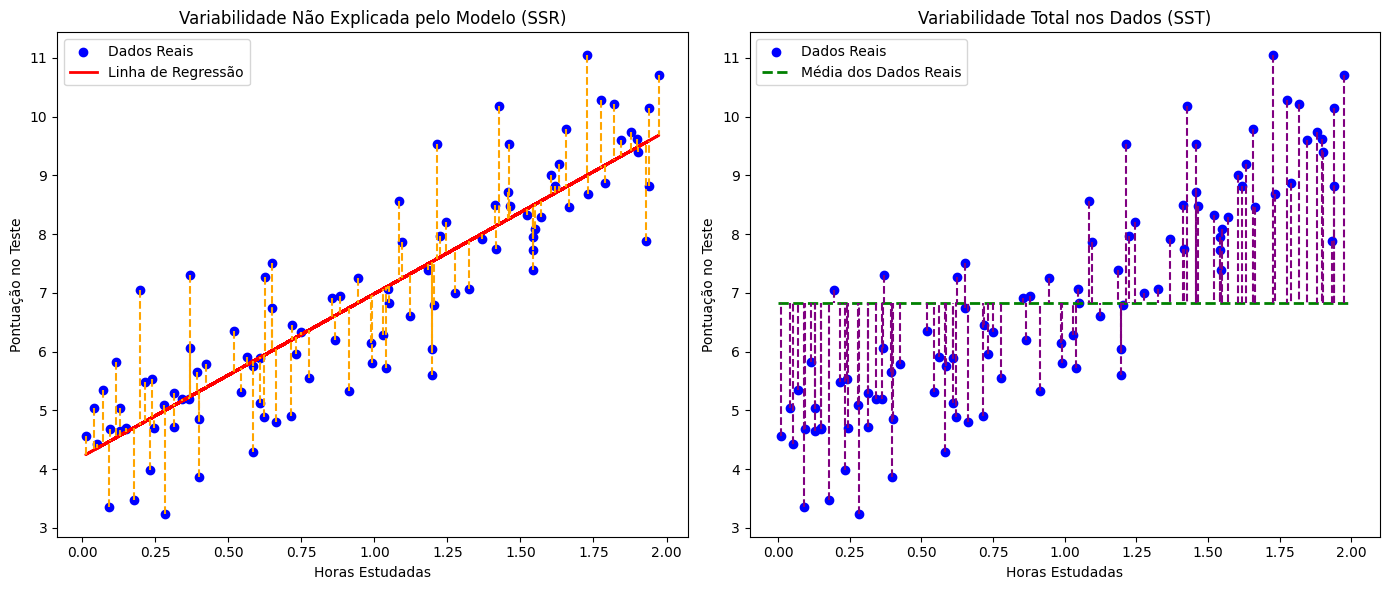

In [53]:
# Criar as subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Plotar a variabilidade não explicada (SSR)
axs[0].scatter(X, y, color='blue', label='Dados Reais')
axs[0].plot(X, y_pred, color='red', linewidth=2, label='Linha de Regressão')
for i in range(len(X)):
    axs[0].plot([X[i], X[i]], [y[i], y_pred[i]], color='orange', linestyle='dashed')
axs[0].set_title('Variabilidade Não Explicada pelo Modelo (SSR)')
axs[0].set_xlabel('Horas Estudadas')
axs[0].set_ylabel('Pontuação no Teste')
axs[0].legend()

# Plotar a variabilidade total (SST)
axs[1].scatter(X, y, color='blue', label='Dados Reais')
axs[1].hlines(y=y_mean, xmin=0, xmax=2, color='green', linestyle='dashed', linewidth=2, label='Média dos Dados Reais')
for i in range(len(X)):
    axs[1].plot([X[i], X[i]], [y[i], y_mean], color='purple', linestyle='dashed')
axs[1].set_title('Variabilidade Total nos Dados (SST)')
axs[1].set_xlabel('Horas Estudadas')
axs[1].set_ylabel('Pontuação no Teste')
axs[1].legend()

# Mostrar os gráficos
plt.tight_layout()
plt.show()

### MSE (Mean Squared Error)

- **Definição:** É a média dos quadrados dos erros entre os valores previstos e os valores reais.
- **Interpretação:** Quanto menor o MSE, melhor o modelo. Penaliza mais os erros grandes do que os erros pequenos.
- **Função:**  pode ser utilizado o pacote do sklearn `mse = mean_squared_error(y, y_pred)`

#### Explicação Detalhada do MSE

O Mean Squared Error (MSE) é uma métrica utilizada para avaliar a performance de um modelo de regressão. Ele calcula a média dos quadrados das diferenças entre os valores observados (reais) e os valores preditos pelo modelo. A fórmula do MSE é:

$ \text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $

onde:
- $ y_i $ são os valores reais,
- $ \hat{y}_i $ são os valores preditos pelo modelo,
- $ n $ é o número de observações.

O MSE penaliza erros grandes mais severamente do que erros pequenos devido ao uso do quadrado das diferenças. Um MSE menor indica um modelo com melhor performance, enquanto um MSE maior indica um modelo com pior performance.

##### Calculando manualmente - MSE


In [54]:
# Calculando manualmente

# Calcular a soma dos quadrados dos resíduos (SSR)
ssr = np.sum((y - y_pred) ** 2)
# Médias dos valores
mse_manual = ssr/len(y)

print(f"Mean Squared Error (MSE): {mse_manual:.2f}")

Mean Squared Error (MSE): 0.81


##### Calculando com *sickit-learn* - MSE


In [55]:
# Calcular o MSE
# Passa-se os valores reais (y), os valores obtidos do modelo (y_pred)
# o valor do erro é guardado em mse
mse = mean_squared_error(y, y_pred)
print(f'Mean Squared Error (MSE): {mse:.2f}')

Mean Squared Error (MSE): 0.81


#### Visualização dos Resíduos ao Quadrado

1. **Primeiro Gráfico (Resíduos ao Quadrado)**:
    - Os pontos azuis representam os dados reais.
    - A linha vermelha representa a linha de regressão ajustada pelo modelo.
    - As linhas tracejadas laranja e os pontos laranja representam os **erros individuais ao quadrado**, mostrando as diferenças entre os valores observados e preditos.
2. **Segundo Gráfico (MSE)**:
    - Os pontos azuis representam os dados reais.
    - A linha vermelha representa a linha de regressão ajustada pelo modelo.
    - A linha tracejada roxa horizontal representa plota o Erro Quadrático Médio (MSE), que é a média dos resíduos ao quadrado.

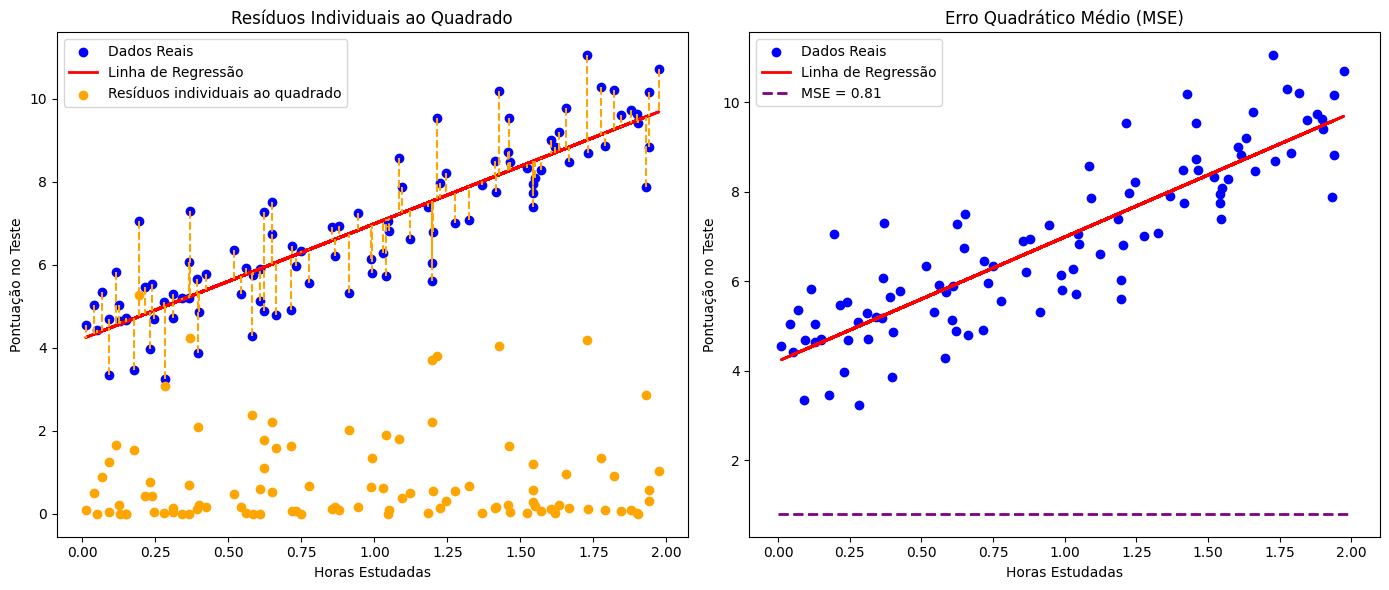

In [56]:
# Criar as subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Plotar os resíduos individuais ao quadrado
axs[0].scatter(X, y, color='blue', label='Dados Reais')
axs[0].plot(X, y_pred, color='red', linewidth=2, label='Linha de Regressão')
for i in range(len(X)):
    axs[0].plot([X[i], X[i]], [y[i], y_pred[i]], color='orange', linestyle='dashed')
axs[0].scatter(X, (y - y_pred)**2, color='orange', label='Resíduos individuais ao quadrado')
axs[0].set_title('Resíduos Individuais ao Quadrado')
axs[0].set_xlabel('Horas Estudadas')
axs[0].set_ylabel('Pontuação no Teste')
axs[0].legend()

# Plotar o MSE
axs[1].scatter(X, y, color='blue', label='Dados Reais')
axs[1].plot(X, y_pred, color='red', linewidth=2, label='Linha de Regressão')
axs[1].hlines(y=mse, xmin=0, xmax=2, color='purple', linestyle='dashed', linewidth=2, label=f'MSE = {mse:.2f}')
axs[1].set_title('Erro Quadrático Médio (MSE)')
axs[1].set_xlabel('Horas Estudadas')
axs[1].set_ylabel('Pontuação no Teste')
axs[1].legend()

# Mostrar os gráficos
plt.tight_layout()
plt.show()

### Mean Absolute Error (MAE)

- **Definição:** É a média dos valores absolutos dos erros entre os valores previstos e os valores reais.
- **Interpretação:** Quanto menor o MAE, melhor o modelo. Penaliza de forma linear todos os erros.
- **Função:**  pode ser utilizado o pacote do sklearn `mae = mean_absolute_error(y, y_pred)`

O MAE mede a magnitude média dos erros em um conjunto de previsões, sem considerar sua direção. É uma métrica linear, o que significa que todos os erros são ponderados igualmente.

#### Explicação Detalhada do MAE

O Mean Absolute Error (MAE) é definido como:

$ \text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i| $

onde:
- $ y_i $ são os valores reais,
- $ \hat{y}_i $ são os valores preditos pelo modelo,
- $ n $ é o número de observações.

##### Calculando manualmente - MAE

In [57]:
# Cálculo manual do MAE
err_abs = abs(y - y_pred)
# Somam-se os erros
sum_erros = np.sum(err_abs)
# Calcula o MAE
mae_manual = sum_erros/len(y)
# Impressão do resultado obtido
print(f'Mean Absolute Error (MAE): {mae_manual:.2f}')

Mean Absolute Error (MAE): 0.70


##### Calculando com *sickit-learn* - MAE

In [58]:
# Calcular o MAE com o uso do sklearn
# Passa-se os valores reais (y), os valores obtidos do modelo (y_pred)
# o valor do erro é guardado em mae
mae = mean_absolute_error(y, y_pred)
print(f'Mean Absolute Error (MAE): {mae:.2f}')

Mean Absolute Error (MAE): 0.70


#### Visualização dos Erros Absolutos e MAE

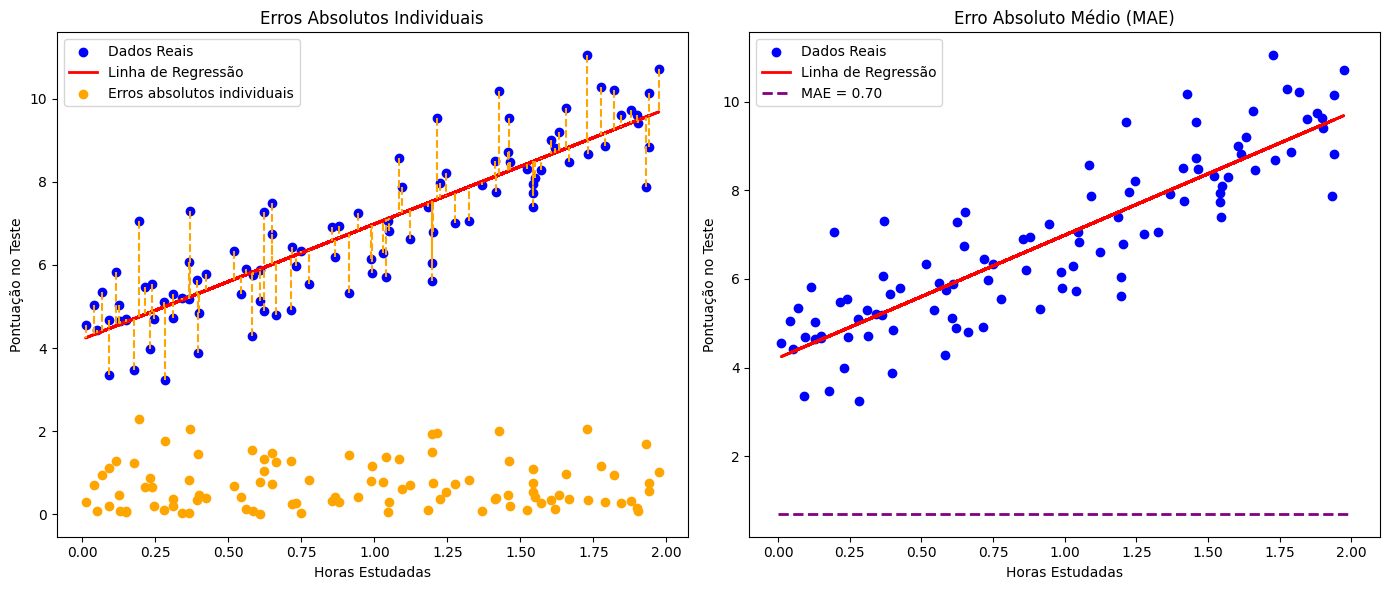

In [59]:
# Criar as subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Plotar os erros absolutos individuais
axs[0].scatter(X, y, color='blue', label='Dados Reais')
axs[0].plot(X, y_pred, color='red', linewidth=2, label='Linha de Regressão')
for i in range(len(X)):
    axs[0].plot([X[i], X[i]], [y[i], y_pred[i]], color='orange', linestyle='dashed')
axs[0].scatter(X, abs(y - y_pred), color='orange', label='Erros absolutos individuais')
axs[0].set_title('Erros Absolutos Individuais')
axs[0].set_xlabel('Horas Estudadas')
axs[0].set_ylabel('Pontuação no Teste')
axs[0].legend()

# Plotar o MAE
axs[1].scatter(X, y, color='blue', label='Dados Reais')
axs[1].plot(X, y_pred, color='red', linewidth=2, label='Linha de Regressão')
axs[1].hlines(y=mae, xmin=0, xmax=2, color='purple', linestyle='dashed', linewidth=2, label=f'MAE = {mae:.2f}')
axs[1].set_title('Erro Absoluto Médio (MAE)')
axs[1].set_xlabel('Horas Estudadas')
axs[1].set_ylabel('Pontuação no Teste')
axs[1].legend()

# Mostrar os gráficos
plt.tight_layout()
plt.show()

### RMSE (Root Mean Squared Error)

- **Definição:** É a raiz quadrada da média dos quadrados dos erros.
- **Interpretação:** Quanto menor o RMSE, melhor o modelo. Tem a mesma unidade dos dados originais e penaliza mais os erros grandes.

#### Explicação Detalhada do RMSE

O Root Mean Squared Error (RMSE) é definido como:

$ \text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2} $

onde:
- $ y_i $ são os valores reais,
- $ \hat{y}_i $ são os valores preditos pelo modelo,
- $ n $ é o número de observações.

O RMSE penaliza mais severamente grandes erros devido ao uso do quadrado das diferenças, similar ao MSE, mas retorna os erros na mesma unidade dos valores observados.

##### Calculando manualmente - RMSE

In [60]:
# Calcular o RMSE manualmente

# Calcular a soma dos quadrados dos resíduos (SSR)
ssr = np.sum((y - y_pred) ** 2)
# Médias dos valores
mse_manual = ssr/len(y)
# A raiz quadrada da média
rmse_manual = np.sqrt(mse_manual)

print(f'Root Mean Squared Error (RMSE): {rmse_manual:.2f}')

Root Mean Squared Error (RMSE): 0.90


##### Calculando com *sickit-learn* - RMSE

* Problema ao usar: rmse = mean_squared_error(y, y_pred, squared=False)
*  O argumento *squared* não funciona mais, pelo visto;
* A solução (linha 9) foi calcular o quadrado do MSE manualmente para obtenção do RMSE

In [61]:
# Cálculo utilizando o pacote do sklearn
# Passa-se os valores reais (y), os valores obtidos do modelo (y_pred)
# nesse caso o parametro `squared` é necessário para que seja calculado a raiz quadrada do erro
# o valor do erro é guardado em rmse
# rmse = mean_squared_error(y, y_pred, squared=False)

# nova solução
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)

# Impressão dos resultados obtidos
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')

Root Mean Squared Error (RMSE): 0.90


In [62]:
import sklearn
print(f" Versão do sklearn: {sklearn.__version__}")

 Versão do sklearn: 1.6.1
